In [1]:
%load_ext autoreload
%autoreload 2 
import numpy as np 
import shap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from Preprocess import preprocess_data
from Preprocess import preprocess_data_window
from xgboost import XGBRegressor
from xgboost.callback import EarlyStopping
from sklearn.metrics import mean_absolute_error
import optuna

c:\Users\kaitl\OneDrive\Documents\Icequake Modeling\Code\Icequake-QRC-\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
data_orig = pd.read_csv("../Whillians-GPS-Data-and-Features.csv")
filtered_time = pd.read_csv("../filtered_time_to_next_event.csv")
#filtered_time = pd.read_csv("filtered_time_normalized.csv", index_col=0)
#data_orig = data_orig.loc[filtered_time.index]


#Testing 182 lag events for classical-only model: 
X_train, X_val, X_test, y_train, y_val, y_test, feature_cols = preprocess_data_window(
    filtered_time,
    data_orig,
    n_previous_events=20
)

X shape:  (2822, 126)
y shape:  (2822,)


In [4]:
# XGBoost


#Tuning XGBoost through the Optuna library
def objective(trial):
  XGBoost = XGBRegressor(
      objective="reg:squarederror",
      n_estimators=1000,
      learning_rate=trial.suggest_float("learning_rate", 0.01, 0.1, log=True), #sweeping 0.01 to 0.1 in the log scale for optimal learning rate
      max_depth=trial.suggest_int("max_depth",2,5), #checking max depth between 2 and 5
      subsample=trial.suggest_float("subsample",0.6,0.9), #sweeping subsample possibilites between 0.6 and 0.9
      colsample_bytree=trial.suggest_float("colsample_bytree",0.6,0.9), #sweeping bytree parameters between 0.6 and 0.9
      random_state=42
  )
  XGBoost.fit(
      X_train, y_train, eval_set=[(X_val, y_val)], verbose=False) #To see more model info set verbose=True
  predictions= XGBoost.predict(X_val)
  RMSE = root_mean_squared_error(y_val, predictions)
  return RMSE

#Finding the parameters that minimize the squared error 
optimization = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42)) # sampler ensures Optuna gives the same tuning results which gives reproducability between runs 
optimization.optimize(objective, n_trials=30) #Keeping at 30 to prevent overfitting with noise

#Showing what the parameters are
optimal_params = optimization.best_params
print("Optimal Parameters:", optimal_params)

#Running the XGBoost with the optimal parameters
XGBoost = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1000,
    **optimal_params,
    random_state=42,
)

XGBoost.fit(
    X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

#Calculating multiplicative error for XGBoost
XGBoost_Prediction = XGBoost.predict(X_test)
XGBoost_RMSE = root_mean_squared_error(y_test, XGBoost_Prediction)
XGBoost_Error = XGBoost_RMSE
print("XGBoost Error:", XGBoost_Error)

XGBoost_RMSE = mean_absolute_error(y_test, XGBoost_Prediction)
XGBoost_Error_MAE = XGBoost_RMSE
print("MAE XGBoost Error:", XGBoost_Error_MAE)

[I 2026-03-19 13:52:44,202] A new study created in memory with name: no-name-8b66b23f-323c-4965-9597-47b02f51ac90
[I 2026-03-19 13:52:47,809] Trial 0 finished with value: 16610.68673179424 and parameters: {'learning_rate': 0.023688639503640783, 'max_depth': 5, 'subsample': 0.8195981825434215, 'colsample_bytree': 0.779597545259111}. Best is trial 0 with value: 16610.68673179424.
[I 2026-03-19 13:52:49,061] Trial 1 finished with value: 17696.51490712202 and parameters: {'learning_rate': 0.014322493718230255, 'max_depth': 2, 'subsample': 0.6174250836504598, 'colsample_bytree': 0.8598528437324806}. Best is trial 0 with value: 16610.68673179424.
[I 2026-03-19 13:52:51,207] Trial 2 finished with value: 16910.393565186347 and parameters: {'learning_rate': 0.039913058785616795, 'max_depth': 4, 'subsample': 0.6061753482887408, 'colsample_bytree': 0.8909729556485984}. Best is trial 0 with value: 16610.68673179424.
[I 2026-03-19 13:52:52,366] Trial 3 finished with value: 17501.307795621797 and pa

Optimal Parameters: {'learning_rate': 0.031580904152223435, 'max_depth': 5, 'subsample': 0.8407951398015077, 'colsample_bytree': 0.8685684874126708}
XGBoost Error: 15156.766613104091
MAE XGBoost Error: 11353.133382881637


165     86910.0
844     89610.0
656     36765.0
4104    65040.0
4901    86820.0
         ...   
4038    87255.0
1137    67740.0
2985    55290.0
3258    54735.0
166     41100.0
Name: time_to_next_ev_hr, Length: 989, dtype: float64
[68866.664 77278.37  53764.812 70870.14  83498.84  49135.887 56822.676
 56965.797 43573.85  59042.375 50920.18  57039.95  68124.88  60553.586
 46616.54  66124.82  68937.17  36541.46  51908.65  57950.895 67204.51
 72878.85  65702.54  62024.637 53874.742 65688.71  70396.85  43496.414
 50769.4   34303.805 49604.586 55544.457 53407.27  66608.05  58614.19
 60688.812 70337.93  88798.08  64545.445 66155.44  60856.336 52053.895
 76836.055 51482.53  60311.656 51501.54  63790.58  40016.805 74189.08
 58671.957 52251.38  62864.902 55232.688 55395.996 73473.375 45403.02
 50843.453 58986.496 52416.816 78303.7   38312.633 62866.938 53135.5
 58325.027 77855.12  44338.13  54987.43  54011.234 67822.41  44649.496
 70179.195 50751.82  38672.574 73901.88  58335.16  50383.598 59726

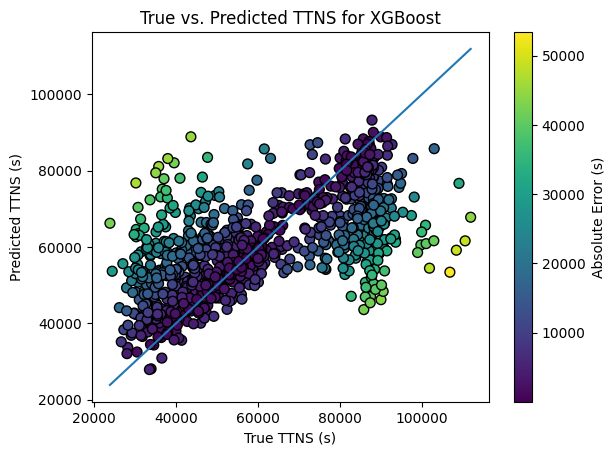

In [4]:
#XGBoost Analysis

#Taking the target column and predictions out of the log scale to calculate the average error in seconds
#y_test_secs = y_test.reshape(1,-1)
y_test_secs = y_test
XG_pred_secs = XGBoost_Prediction
print(y_test_secs)
print(XG_pred_secs)
absolute_error_secs_XG = np.abs(XG_pred_secs - y_test_secs)

#printing the true vs predicted value and error in seconds for every recrod
for i, (true, pred, abs_error) in enumerate(zip(y_test_secs, XG_pred_secs, absolute_error_secs_XG)):
  print(f"Sample{i}: True = {true}s, Predicted = {pred}s, Error={abs_error}s")

# Scatter plot of predicted vs true
plt.figure()
plt.scatter(y_test_secs, XG_pred_secs, c=absolute_error_secs_XG, cmap='viridis', s=50, edgecolors="black")
plt.colorbar(label="Absolute Error (s)")
plt.plot([min(y_test_secs), max(y_test_secs)], [min(y_test_secs), max(y_test_secs)])
plt.xlabel("True TTNS (s)")
plt.ylabel("Predicted TTNS (s)")
plt.title("True vs. Predicted TTNS for XGBoost")
#plt.xscale('log')
#plt.yscale('log')
plt.show()

In [ ]:
# Compute absolute errors
print("Length of Subset", len(XG_pred_secs))
diff = np.abs(XG_pred_secs - y_test_secs)

# Threshold for outliers
threshold = 20000  # adjust as needed

# Get indices of outliers in the test set
X_outliers = np.where(diff > threshold)[0]

print("Number of Outliers", len(X_outliers))
print(f"Outliers (error > {threshold}):")

# Print details for only outliers
for idx in X_outliers:
    true = y_test_secs.iloc[idx]   # pandas Series: use iloc
    pred = XG_pred_secs[idx]       # numpy array: use normal indexing
    print(f"Index position {idx}: True={true}, Predicted={pred}")

Length of Subset 989
Number of Outliers 201
Outliers (error > 20000):
Index position 8: True=85785.0, Predicted=43573.8515625
Index position 13: True=33840.0, Predicted=60553.5859375
Index position 15: True=88605.0, Predicted=66124.8203125
Index position 18: True=31905.000000000004, Predicted=51908.6484375
Index position 20: True=87975.0, Predicted=67204.5078125
Index position 25: True=87960.0, Predicted=65688.7109375
Index position 51: True=89130.0, Predicted=62864.90234375
Index position 53: True=30600.0, Predicted=55395.99609375
Index position 54: True=49485.0, Predicted=73473.375
Index position 64: True=37035.0, Predicted=77855.1171875
Index position 71: True=30644.999999999996, Predicted=50751.8203125
Index position 74: True=83999.99999999999, Predicted=58335.16015625
Index position 76: True=81090.0, Predicted=59726.66796875
Index position 80: True=89685.0, Predicted=65220.73828125
Index position 82: True=90675.0, Predicted=59821.05859375
Index position 83: True=85020.0, Predicted

: 

In [ ]:
# Driving parameters for XG 

#Using the shap library with a copy of the training data to find the driving parameters
X_shap = X_test.copy()
X_shap = pd.DataFrame(X_shap, columns=feature_cols)
explainer_XG = shap.TreeExplainer(XGBoost, X_shap, feature_perturbation="interventional") #Using interventional to respect correlation between the features

shap_values_XG = explainer_XG.shap_values(X_shap) #Doing the tree analysis on XG using training data

XG_imp = pd.Series(np.abs(shap_values_XG).mean(axis=0), index=X_shap.columns).sort_values(ascending=False) #Analysis of driving parameters in XG

print("XG Boost Drivers:", XG_imp)

# Creating a bar graph showing the driving parameters for XGBoost 
plt.figure(figsize=(10, 6))
plt.xticks(fontsize=14)   # <-- Increase x-axis label size
plt.yticks(fontsize=12)
XG_imp.sort_values(ascending=False).plot(kind="bar")
plt.title("XG Boost Drivers", fontsize=20)
plt.ylabel("Mean Absolute SHAP Value", fontsize=18)
plt.xlabel("Feature", fontsize=18)
plt.show()
